In [1]:
# !pip install xgboost
import pandas as pd
from collections import defaultdict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib import font_manager
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
import seaborn as sns
import joblib
import os
import xgboost as xgb

font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 12})

In [2]:
def formatter(x, pos):
    if x != 0:
        return f'{int(x/1000)}k'
    else:
        return 0

# For some reason loading in the files and predicting the test set results in weird/bad performance. Perhaps this should be looked into... For now, I have just retrained the models from scratch, which seemed to have worked.

In [9]:
basis = "STO_3G"
n = 20

fn = f"out/{basis}_xgb_model_{n}.json"
model = xgb.XGBRegressor()
model.load_model(fn)
print("Model loaded.")

# splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_{basis}_data_splits_{n}.pkl")
splits_fn = os.path.join(os.path.expanduser("~"), "out", f"faster_sto_3g_pVDZ_data_splits_20.pkl")

# splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_STO-3G_data_splits_{n}.pkl"
data = joblib.load(splits_fn)
print("Data splits loaded.")


scaler = MinMaxScaler(feature_range=(-1,1))
X_train = scaler.fit_transform(data["X_train"])
y_train = data["y_train"]

X_test = scaler.transform(data["X_test"])
y_test = data["y_test"]

y_pred = model.predict(X_test)
error = y_pred - y_test
print("Predicted test set.")

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")

Model loaded.
Data splits loaded.
Predicted test set.
N: 20, MAE: 0.00022612851535391197, MSE: 7.514063191818838e-07, R2: 0.9861144058567034


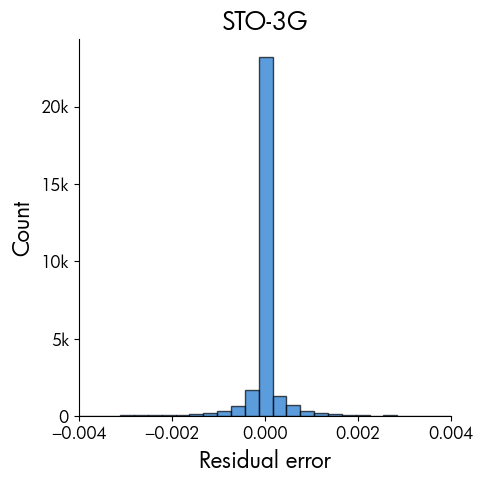

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error, bins=200, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.004,0.004)
plt.title("STO-3G", fontsize=18)
plt.tight_layout()
plt.show()

In [5]:
data = joblib.load(splits_fn)
X_train = data["X_train"]
y_train = data["y_train"]
X_test = data["X_test"]
y_test = data["y_test"]

 
model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

model_pipeline = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(-1,1))),
    ('regressor', model)
])

model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")

N: 20, MAE: 0.0002249105611224731, MSE: 7.421556272990529e-07, R2: 0.9862853537842768


In [6]:
error = y_pred - y_test

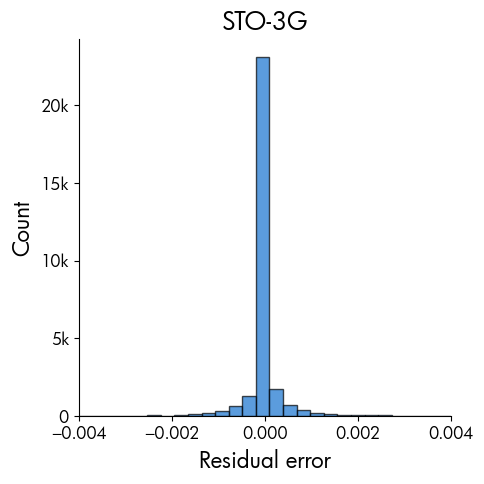

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error, bins=200, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.004,0.004)
plt.title("STO-3G", fontsize=18)
plt.tight_layout()
plt.show()

In [7]:
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_cc-pVDZ_data_splits_{n}.pkl"
data = joblib.load(splits_fn)
X_train_2 = data["X_train"]
y_train_2 = data["y_train"]
X_test_2 = data["X_test"]
y_test_2 = data["y_test"]

 
model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

model_pipeline = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(-1,1))),
    ('regressor', model)
])

model_pipeline.fit(X_train_2, y_train_2)
y_pred_2 = model_pipeline.predict(X_test_2)

r2 = r2_score(y_test_2, y_pred_2)
mae = mean_absolute_error(y_test_2, y_pred_2)
mse = mean_squared_error(y_test_2, y_pred_2)

print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")

N: 20, MAE: 4.9548887360112236e-05, MSE: 1.578525723803782e-07, R2: 0.887979990222034


In [8]:
error_2 = y_pred_2 - y_test_2

In [9]:
splits_fn = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_aug-cc-pVDZ_data_splits_{n}.pkl"
data = joblib.load(splits_fn)
X_train_3 = data["X_train"]
y_train_3 = data["y_train"]
X_test_3 = data["X_test"]
y_test_3 = data["y_test"]

 
model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

model_pipeline = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(-1,1))),
    ('regressor', model)
])

model_pipeline.fit(X_train_3, y_train_3)
y_pred_3 = model_pipeline.predict(X_test_3)

r2 = r2_score(y_test_3, y_pred_3)
mae = mean_absolute_error(y_test_3, y_pred_3)
mse = mean_squared_error(y_test_3, y_pred_3)

print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")

N: 20, MAE: 3.0053834475269777e-05, MSE: 4.5686902206794934e-08, R2: 0.893603494891275


In [10]:
error_3 = y_pred_3 - y_test_3

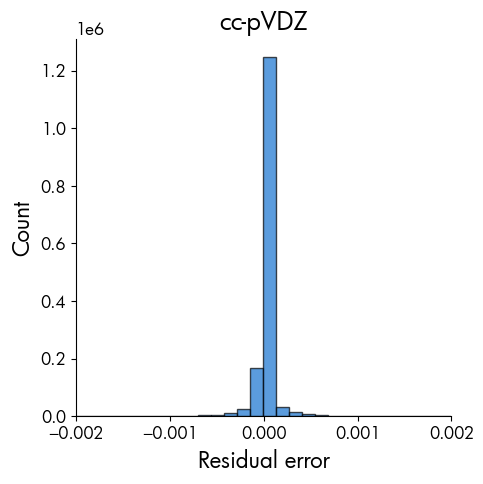

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error_2, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

#ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.002,0.002)
plt.title("cc-pVDZ", fontsize=18)
plt.tight_layout()
plt.show()

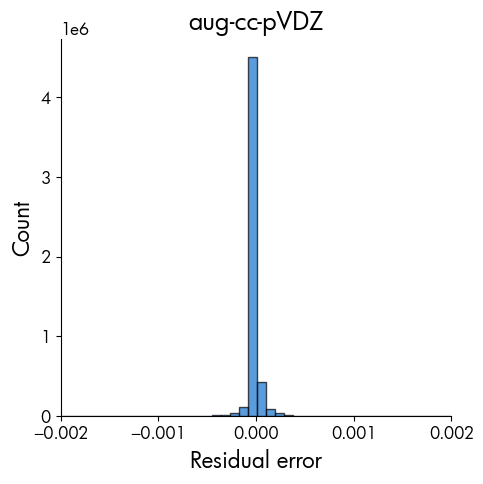

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(error_3, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')

ax.set_xlabel('Residual error', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

#ax.yaxis.set_major_formatter(FuncFormatter(formatter))
plt.gca().spines['top'].set_color('none')
plt.gca().spines['right'].set_color('none')

plt.xlim(-0.002,0.002)
plt.title("aug-cc-pVDZ", fontsize=18)
plt.tight_layout()
plt.show()

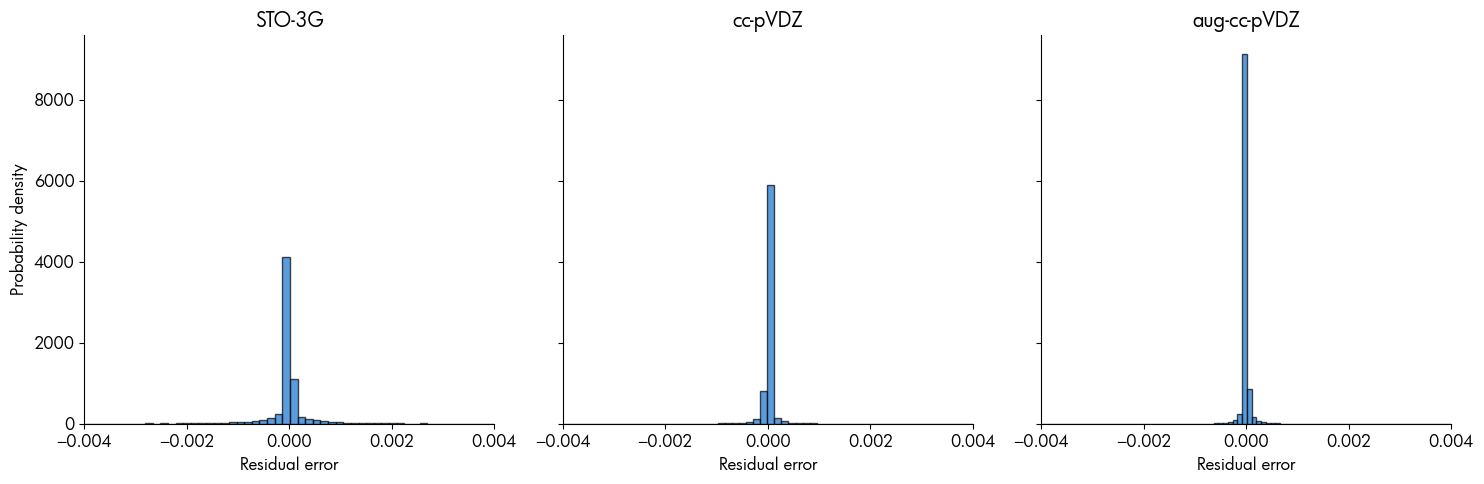

In [13]:
errors = [error, error_2, error_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]
bins_sizes = [400, 1000, 1000]
# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
xticks = [-0.004, -0.002, 0.0, 0.002, 0.004]
for i, (err, title) in enumerate(zip(errors, titles)):
    #axs[i].hist(err, bins=1000, edgecolor='black', alpha=0.7, color='#1573CF')
    axs[i].hist(err, bins=bins_sizes[i], edgecolor='black', alpha=0.7, color='#1573CF', density=True)
    axs[0].set_ylabel('Probability density')
    axs[i].set_xlabel('Residual error')
    axs[i].set_xlim(-0.002, 0.002)
    axs[i].set_xticks(xticks)
    axs[i].set_title(title)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')
    #axs[i].set_yscale('log')
    #axs[i].yaxis.set_major_formatter(FuncFormatter(formatter))

axs[0].set_ylabel('Probability density')


plt.tight_layout()
plt.show()

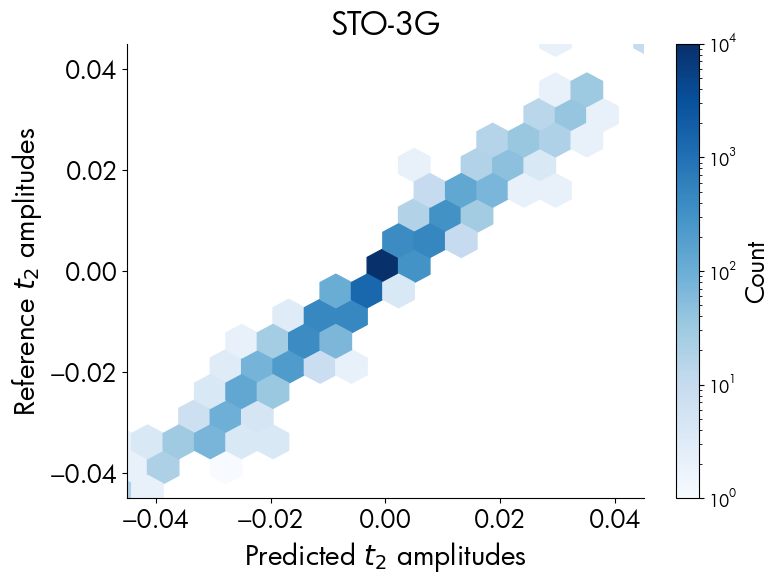

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred, y_test, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("STO-3G", fontsize=23)

plt.tight_layout()
plt.savefig("ref_pred.svg", format='svg', dpi=300)
plt.show()

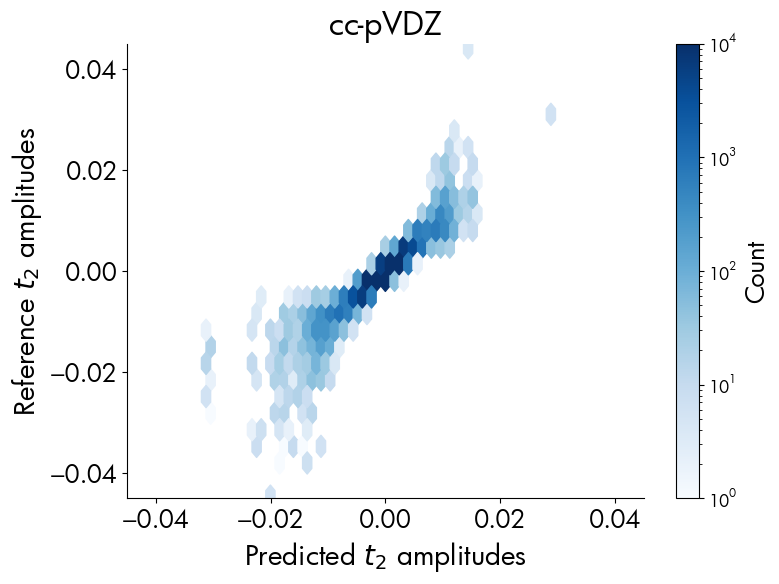

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred_2, y_test_2, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("cc-pVDZ", fontsize=23)

plt.tight_layout()
plt.savefig("ref_pred.svg", format='svg', dpi=300)
plt.show()

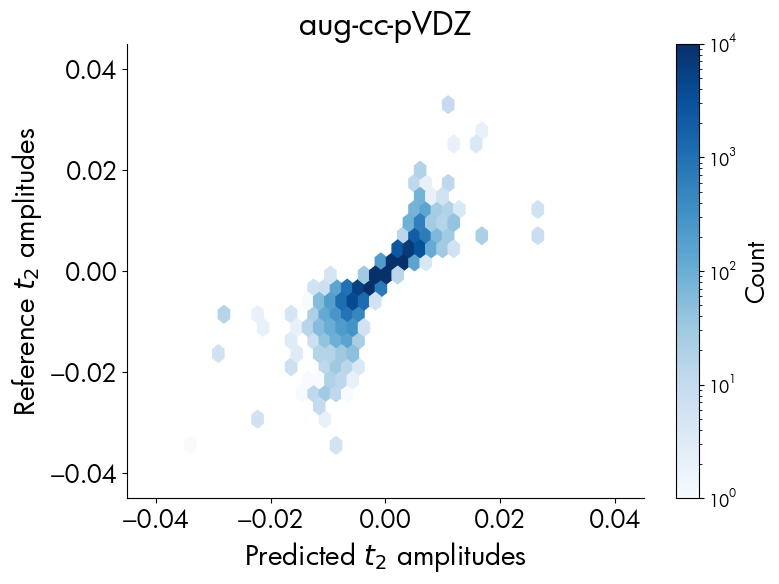

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(y_pred_3, y_test_3, gridsize=50, cmap='Blues', norm=LogNorm(vmin=1, vmax=10_000))

ax.set_xlabel('Predicted $t_2$ amplitudes', fontsize=20)
ax.set_ylabel('Reference $t_2$ amplitudes', fontsize=20)

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

xticks = [-0.04, -0.02, 0.00, 0.02, 0.04]
ax.set_xticks(xticks)
ax.set_yticks(xticks)
ax.tick_params(axis='both', labelsize=18)

ax.set_xlim(-0.045, 0.045)
ax.set_ylim(-0.045, 0.045)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count', fontsize=18)
ax.set_title("aug-cc-pVDZ", fontsize=23)

plt.tight_layout()
plt.savefig("ref_pred.svg", format='svg', dpi=300)
plt.show()

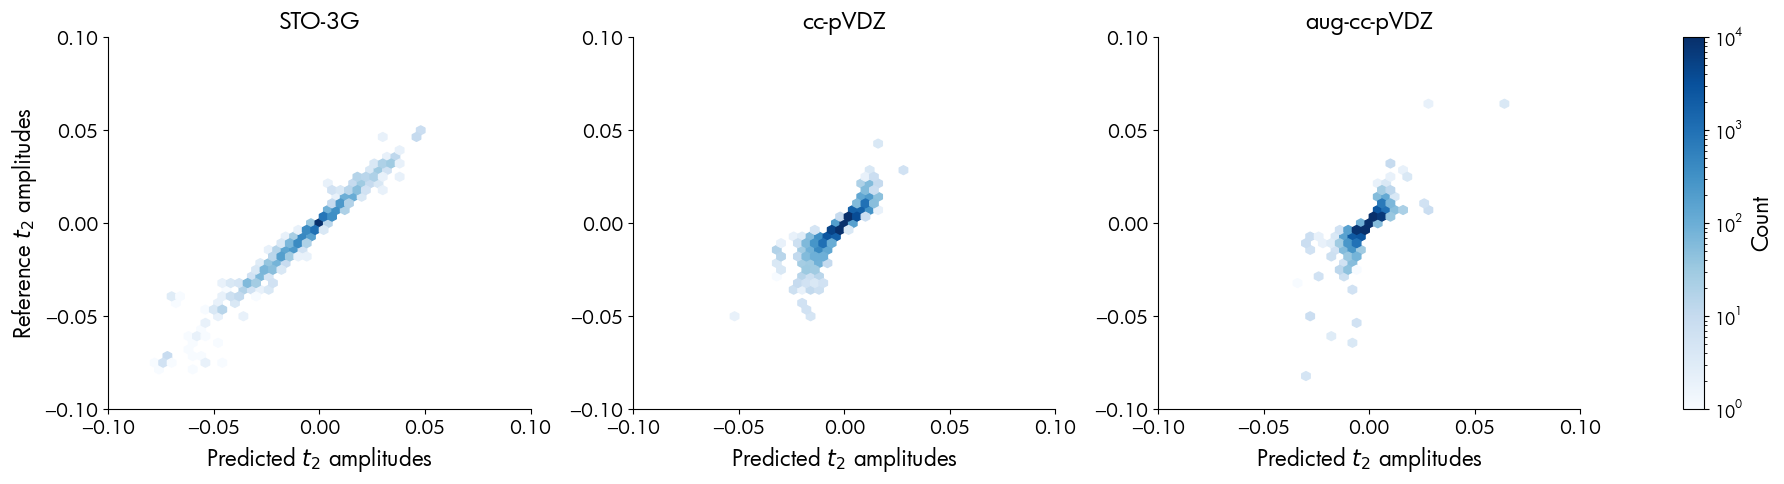

In [33]:
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05]) 

predictions = [y_pred, y_pred_2, y_pred_3]
tests_subsets = [y_test, y_test_2, y_test_3]
titles = ["STO-3G", "cc-pVDZ", "aug-cc-pVDZ"]

axs = [plt.subplot(gs[i]) for i in range(3)]

for i, (y_p, title) in enumerate(zip(predictions, titles)):
    hb = axs[i].hexbin(
        y_p, tests_subsets[i],
        gridsize=50,
        cmap='Blues',
        norm=LogNorm(vmin=1, vmax=10_000),
        extent=(-0.1, 0.1, -0.1, 0.1)
    )
    axs[i].set_title(title, fontsize=17)
    axs[i].set_xlim(-0.1, 0.1)
    axs[i].set_ylim(-0.1, 0.1)

    xticks = [-0.1, -0.05, 0.00, 0.05, 0.1]
    axs[i].set_xticks(xticks)
    axs[i].set_yticks(xticks)
    axs[i].tick_params(axis='both', labelsize=14)


    axs[i].set_xlabel('Predicted $t_2$ amplitudes', fontsize=16)
    axs[i].spines['top'].set_color('none')
    axs[i].spines['right'].set_color('none')

axs[0].set_ylabel('Reference $t_2$ amplitudes', fontsize=16)

cax = plt.subplot(gs[3])
cbar = fig.colorbar(hb, cax=cax)
cbar.set_label('Count', fontsize=16)

plt.tight_layout()
plt.savefig("combined_pred.svg", format='svg', dpi=300)
plt.show()

## STO-3G performance
N: 20, MAE: 0.0002330152269207157, MSE: 7.532092223466864e-07, R2: 0.9860810891530944 <br>
N: 20, MAE: 0.0002330152269207157, MSE: 7.532092223466864e-07, R2: 0.9860810891530944 <br>
N: 40, MAE: 0.0002176263665407508, MSE: 5.681371028847376e-07, R2: 0.989501124721715 <br>
N: 60, MAE: 0.0002014400357812678, MSE: 5.077976929190731e-07, R2: 0.9906161653278965 <br> 
N: 80, MAE: 0.00019647668561375374, MSE: 4.776372338980758e-07, R2: 0.9911735147704686 <br>
N: 100, MAE: 0.00019005345457551788, MSE: 3.7697602708236656e-07, R2: 0.9930336810056144

## cc-pVDZ performance

N: 20, MAE: 4.9548887360112236e-05, MSE: 1.578525723803782e-07, R2: 0.887979990222034 <br>
N: 40, MAE: 4.864859705460949e-05, MSE: 1.486136602734458e-07, R2: 0.8945363802063697 <br>
N: 60, MAE: 4.82518460149982e-05, MSE: 1.4741003204927914e-07, R2: 0.8953905344555337 <br>
N: 80, MAE: 4.8161815205708346e-05, MSE: 1.496407150232706e-07, R2: 0.8938075312469708 <br>
N: 100, MAE: 4.8152450458069116e-05, MSE: 1.5177392161798446e-07, R2: 0.8922937021088403

## aug-cc-pVDZ performance
N: 20, MAE: 3.025909673030582e-05, MSE: 4.615545334126103e-08, R2: 0.8925123243201938 <br>
N: 20, MAE: 3.0053834475269777e-05, MSE: 4.5686902206794934e-08, R2: 0.893603494891275 <br>
N: 40, MAE: 2.9439605541940332e-05, MSE: 4.0244244814937795e-08, R2: 0.9062784563578382 <br>
N: 60, MAE: 2.9506030088550187e-05, MSE: 4.000266999471409e-08, R2: 0.9068410402791058 <br>
N: 80, MAE: 2.9544968163505723e-05, MSE: 4.1864749762302006e-08, R2: 0.9025045943846509

In [36]:
samples = [20, 40, 60, 80]

theory = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ']

mae_results = {
    'STO-3G': [
        0.0002330152269207157,
        0.0002176263665407508,
        0.0002014400357812678,
        0.00019647668561375374
    ],
    'cc-pVDZ': [
        4.9548887360112236e-05,
        4.864859705460949e-05,
        4.82518460149982e-05,
        4.8161815205708346e-05
    ],
    'aug-cc-pVDZ': [
        3.0053834475269777e-05,
        2.9439605541940332e-05,
        2.9506030088550187e-05,
        2.9544968163505723e-05
    ]
}

mse_results = {
    'STO-3G': [
        7.532092223466864e-07,
        5.681371028847376e-07,
        5.077976929190731e-07,
        4.776372338980758e-07
    ],
    'cc-pVDZ': [
        1.578525723803782e-07,
        1.486136602734458e-07,
        1.4741003204927914e-07,
        1.496407150232706e-07
    ],
    'aug-cc-pVDZ': [
        4.5686902206794934e-08,
        4.0244244814937795e-08,
        4.000266999471409e-08,
        4.1864749762302006e-08
    ]
}

r2_results = {
    'STO-3G': [
        0.9860810891530944,
        0.989501124721715,
        0.9906161653278965,
        0.9911735147704686
    ],
    'cc-pVDZ': [
        0.887979990222034,
        0.8945363802063697,
        0.8953905344555337,
        0.8938075312469708
    ],
    'aug-cc-pVDZ': [
        0.893603494891275,
        0.9062784563578382,
        0.9068410402791058,
        0.9025045943846509
    ]
}


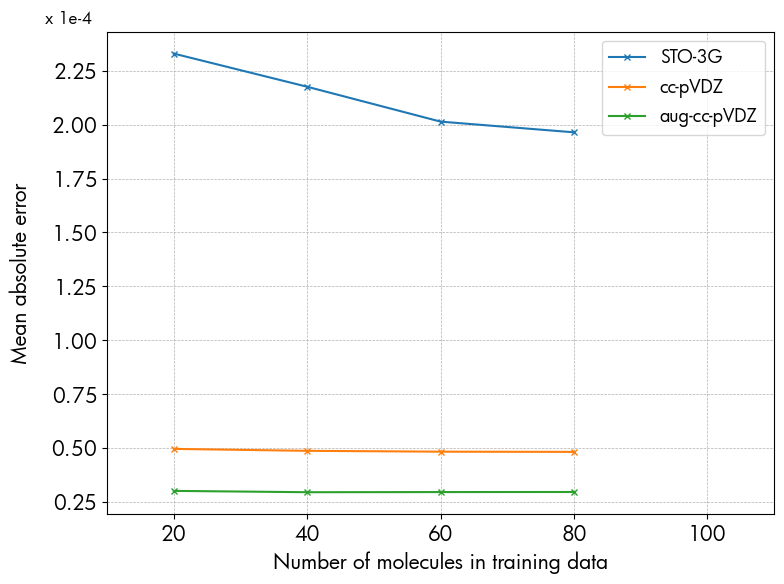

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, mae in mae_results.items():
    scaled_mae = [m*1e4 for m in mae]
    ax.plot(samples, scaled_mae, 'x-', label=model, markersize=4)


#ax.set_yscale("log")

ax.set_xlabel("Number of molecules in training data", fontsize=15)
ax.set_ylabel("Mean absolute error", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-4, -4))
ax.yaxis.set_major_formatter(formatter)

ax.ticklabel_format(style='plain', axis='y')
ax.tick_params(axis='both', which='major', labelsize=15)

ax.annotate("x 1e-4", xy=(0, 1), xycoords=('axes fraction', 'axes fraction'),
            xytext=(-45, 3), textcoords='offset points',
            ha='left', va='bottom', fontsize=12)

ax.legend(fontsize=13)
plt.tight_layout()
plt.xlim(10, 110)
plt.show()

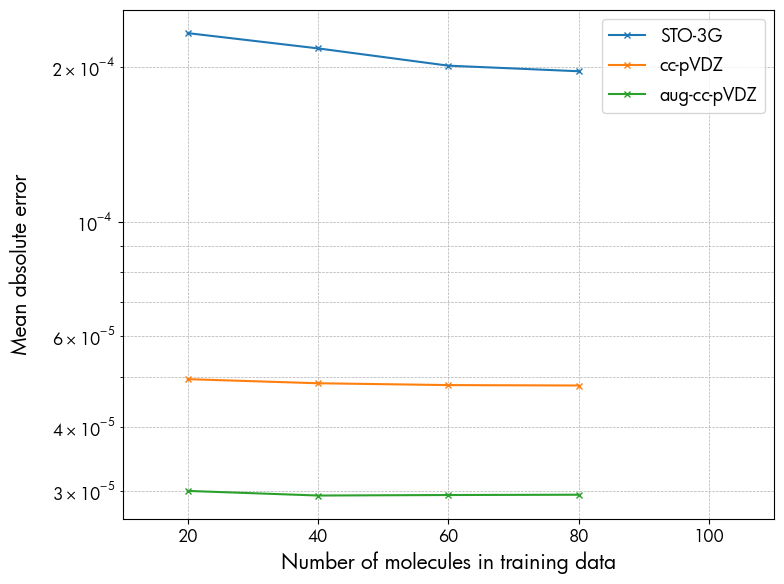

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))

for model, mae in mae_results.items():
    ax.plot(samples, mae, 'x-', label=model, markersize=4)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(LogFormatterSciNotation())

ax.set_xlabel("Number of molecules in training data", fontsize=15)
ax.set_ylabel("Mean absolute error", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

ax.legend(fontsize=13)
plt.tight_layout()
plt.xlim(10, 110)
plt.show()

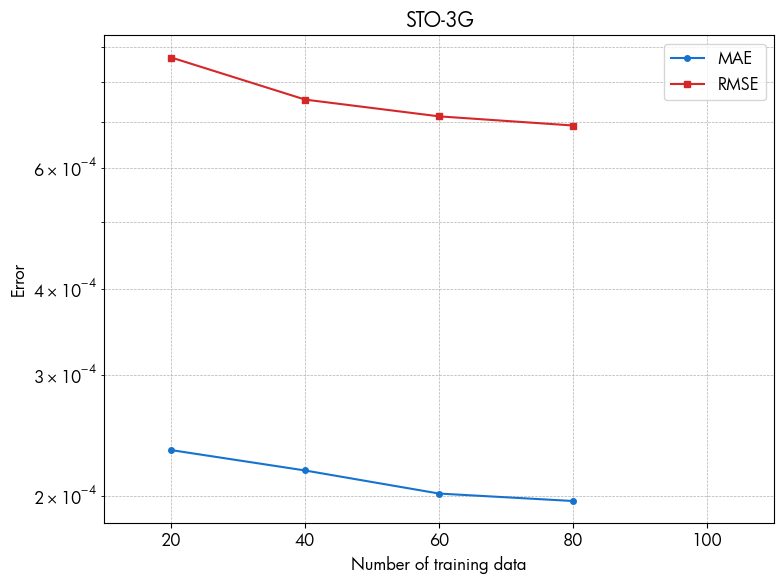

In [78]:
rmse = np.sqrt(mse_results['STO-3G'])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(samples, mae_results['STO-3G'], 'o-', label='MAE', color='#1573CF', markersize=4)
ax.plot(samples, rmse, 's-', label='RMSE', color='tab:red', markersize=4)

ax.set_yscale("log")
ax.set_xlabel("Number of training data")
ax.set_ylabel("Error")

plt.xlim(10, 110)

ax.legend()
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title("STO-3G")
plt.tight_layout()
plt.show()

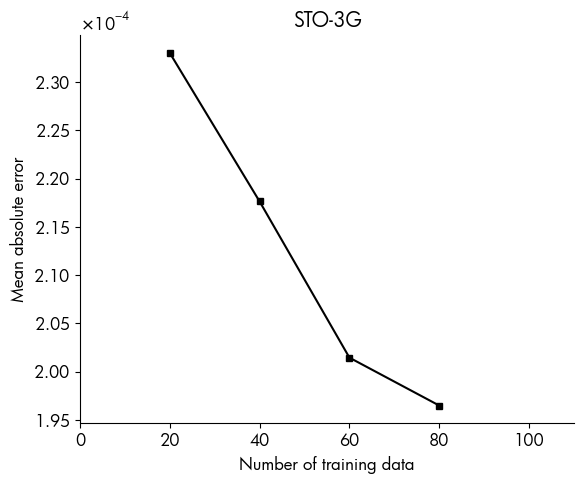

In [82]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(samples, mae_results['STO-3G'], 's-', label='MAE', color='black', markersize=5)

ax.set_xlabel("Number of training data")
ax.set_ylabel("Mean absolute error")

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

#ax.set_yscale("log")

# Use scalar formatter with scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-4, -4))  # Force 10^-4 scaling
ax.yaxis.set_major_formatter(formatter)

plt.xlim(0, 110)
plt.title("STO-3G")
plt.tight_layout()
plt.show()


# Average over molecules

In [1]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
#import tensorflow as tf
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.metrics import mean_absolute_error, r2_score

from glob import glob
import psi4
from helper_CC_ML_spacial import HelperCCEnergy
# from helper_CC_ML import *

from glob import glob
import random

  Threads set to 12 by Python driver.


In [2]:
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag']

In [3]:
with open('out_of_data.txt','r') as f:
    lines = f.readlines()
    
filenames = [element[:-1] for element in lines]
filenames[:4]

['../machine_learning/data/methane72.xyz',
 '../machine_learning/data/ammonia159.xyz',
 '../machine_learning/data/methane5.xyz',
 '../machine_learning/data/water91.xyz']

In [51]:
basis_sets = ['STO-3G','cc-pVDZ','aug-cc-pVDZ']
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

n_list = [20, 40, 60, 80, 100] # iterating over N=20,40,60,80,100 training molecules
n_list = [20]
mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")

        data_path = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_{basis}_data_splits_{n}.pkl"
        print(data_path)
        print("Training model..")

        with open(data_path,'rb') as f:
            data = joblib.load(f)            # import model

        X_train = data["X_train"]
        y_train = data["y_train"]
        X_test = data["X_test"]
        y_test = data["y_test"]
        
         
        model = xgb.XGBRegressor(
            n_estimators=400,
            max_depth=12,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            tree_method="hist",
            n_jobs=-1,
            random_state=42
        )
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames[:50]:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
            # Here is the "normal" way to initialize i.e. NOT Machine Learning predicted, NOT random, NOT all zeros
            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2

            # GMJ go back and fix these lists to save this data
            MP2E = A.compute_energy(iterate=False)# MP2 (initial) energy
            CCSDE = A.compute_energy()# exact CCSD energy
        
            normal_dev.append(abs(MP2E-CCSDE))  # energy deviation from CCSD
            
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in best5]).T)
            
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            # mlE_0 = A.compute_energy(iterate=False)   # GMJ this is MP2 energy
            mlE = A.compute_energy()                # GMJ exact CCSD energy calculated using injected DDCC parameters 
                    
            ml_dev.append(abs(MP2E-mlE))  # energy deviation from MP2
            ml_dev.append(abs(CCSDE-mlE))  # energy deviation from CCSD
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


Processing N=20 molecules with STO-3G basis set
/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_STO-3G_data_splits_20.pkl
Training model..
N: 20, MAE: 0.00022612851535391197, MSE: 7.514063191818838e-07, R2: 0.9861144058567034
Finished training in -48.05548667907715 seconds 

Processing ../machine_learning/data/methane72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.116 seconds.

CCSD Iteration   0: CCSD correlation = -0.045420775701298   dE =  4.54208E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.045420775701298   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.045420775701298   dE =  4.54208E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.069391584627120   dE = -2.39708E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.075838024924073   dE = -6.44644E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.078654783631846   dE = -2.81676E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.078965937040208   dE = -3.11153E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.079039342506054   dE = -7.34055E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.081 seconds.

CCSD Iteration   0: CCSD correlation = -0.037595770053634   dE =  3.75958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.037595770053634   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.037595770053634   dE =  3.75958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.058239943013197   dE = -2.06442E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.063028437158248   dE = -4.78849E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.064855986930710   dE = -1.82755E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.064925473277907   dE = -6.94863E-05   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.064949605127467   dE = -2.41318E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

...

Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 50 basis functions.
(50, 50)
(49, 49)
Building initial guess...

..initialized CCSD in 0.992 seconds.

CCSD Iteration   0: CCSD correlation = -0.021223637008897   dE =  2.12236E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.021223637008897   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.021223637008897   dE =  2.12236E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.202992564991223   dE = -1.81769E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.209740352479584   dE = -6.74779E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.213522296907928   dE = -3.78194E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.214088454982730   dE = -5.66158E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.214336468057812   dE = -2.48013E-04   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 64 basis functions.
(64, 64)
(62, 62)
Building initial guess...

..initialized CCSD in 3.303 seconds.

CCSD Iteration   0: CCSD correlation = -0.005904035126121   dE =  5.90404E-03   MP2
CCSD Iteration   1: CCSD correlation = -0.005904035126121   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.005 seconds!
CCSD Iteration   0: CCSD correlation = -0.005904035126121   dE =  5.90404E-03   MP2
CCSD Iteration   1: CCSD correlation = -0.335860059423215   dE = -3.29956E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.335867417941423   dE = -7.35852E-06   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.348236740848186   dE = -1.23693E-02   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.348168895531599   dE =  6.78453E-05   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.349337376496560   dE = -1.16848E-03   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 82 basis functions.
(82, 82)
(80, 80)
Building initial guess...

..initialized CCSD in 9.271 seconds.

CCSD Iteration   0: CCSD correlation = -0.053250807935391   dE =  5.32508E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.053250807935391   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.013 seconds!
CCSD Iteration   0: CCSD correlation = -0.053250807935391   dE =  5.32508E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.368889742947464   dE = -3.15639E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.374080167168211   dE = -5.19042E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.381568417980078   dE = -7.48825E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.381860061060691   dE = -2.91643E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.382390506993124   dE = -5.30446E-04   DIIS = 4
CCSD Iteration   6: CCSD correl

In [52]:
mean_deviations

[('STO-3G', 20, np.float64(0.05968167199842092)),
 ('cc-pVDZ', 20, np.float64(0.24125775414230108)),
 ('aug-cc-pVDZ', 20, np.float64(0.25382922349090453))]

In [53]:
mean_iter_to_converge

[('STO-3G', 20, np.float64(12.04)),
 ('cc-pVDZ', 20, np.float64(13.42)),
 ('aug-cc-pVDZ', 20, np.float64(14.52))]

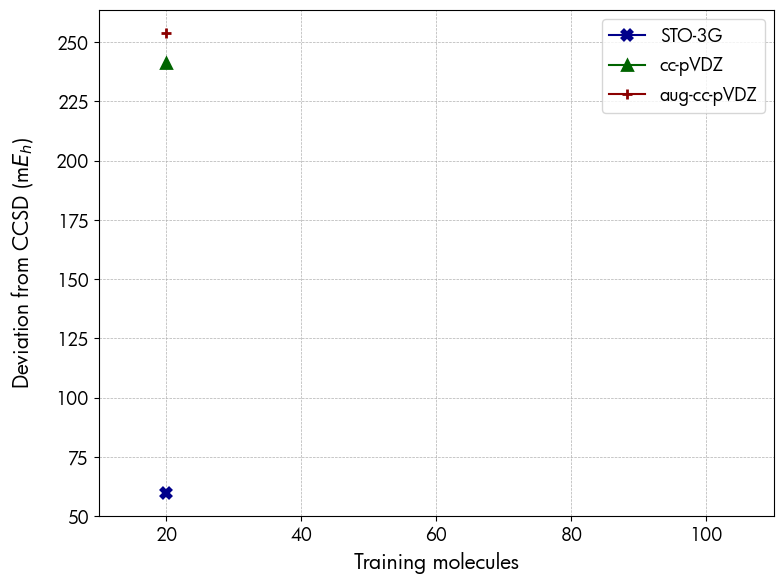

In [54]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

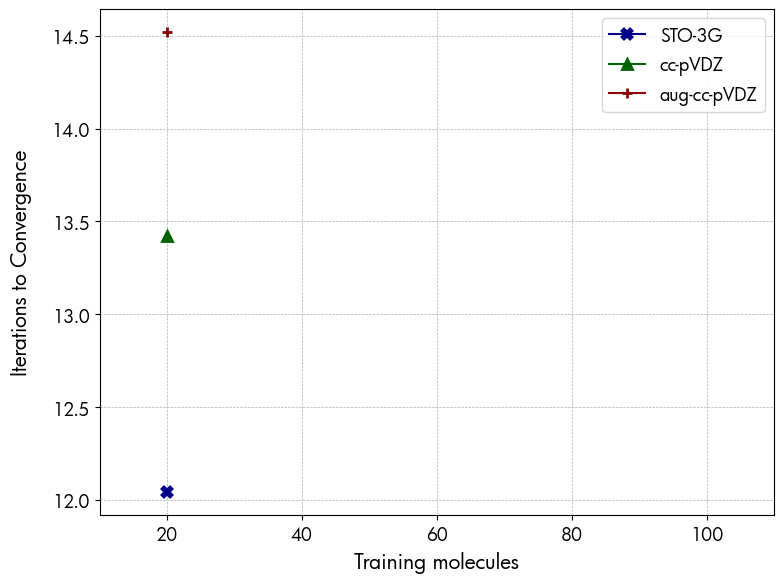

In [55]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to Convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

In [ ]:
################

In [56]:
basis_sets = ['STO-3G']
best5=["doublecheck","t2start","t2mag","orbdiff","diag"]

n_list = [20, 40, 60, 80, 100] # iterating over N=20,40,60,80,100 training molecules
mean_deviations = []
mean_iter_to_converge = []

for basis in basis_sets:
    for n in n_list:
        print(f"Processing N={n} molecules with {basis} basis set")

        data_path = f"/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_{basis}_data_splits_{n}.pkl"
        print(data_path)
        print("Training model..")

        with open(data_path,'rb') as f:
            data = joblib.load(f)            # import model

        X_train = data["X_train"]
        y_train = data["y_train"]
        X_test = data["X_test"]
        y_test = data["y_test"]
        
         
        model = xgb.XGBRegressor(
            n_estimators=400,
            max_depth=12,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            tree_method="hist",
            n_jobs=-1,
            random_state=42
        )
        
        model_pipeline = Pipeline([
            ('scaler', MinMaxScaler(feature_range=(-1,1))),
            ('regressor', model)
        ])

        t1 = time.time()
        model_pipeline.fit(X_train, y_train)
        t2 = time.time()
        
        y_pred = model_pipeline.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        print(f"N: {n}, MAE: {mae}, MSE: {mse}, R2: {r2}")
        print(f"Finished training in {t2-t1} seconds \n")
        
        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        for fn in filenames[:50]:
            print(f"Processing {fn}")       # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)                
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})

            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)

            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in best5]).T)
        
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)

            mlE_0 = A.compute_energy(iterate=False)   # ML-predicted energy
            mlE = A.compute_energy()                # exact CCSD energy
                    
            ml_dev.append(abs(mlE_0-mlE))  # energy deviation from CCSD
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            ml_time_to_converge = A.time_to_converge 
            ml_time_to_converge_list.append(ml_time_to_converge)
            #print(f"Time to converge: {ml_time_to_converge}")
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
            #print(f"Features: \n{features}")

        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", ml_dev)
        print(f"Mean deviation from CCSD: {np.mean(ml_dev)} (Eₕ)")
        print("Times to converge for each molecule: ", ml_time_to_converge_list)
        print("Mean time to converge", np.mean(ml_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(ml_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("Next model...\n")


Processing N=20 molecules with STO-3G basis set
/mnt/c/Users/Maxim/Documents/Toronto/Research/code/out/faster_STO-3G_data_splits_20.pkl
Training model..
N: 20, MAE: 0.00022612851535391197, MSE: 7.514063191818838e-07, R2: 0.9861144058567034
Finished training in 55.42280864715576 seconds 

Processing ../machine_learning/data/methane72.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 9 basis functions.
(9, 9)
(8, 8)
Building initial guess...

..initialized CCSD in 0.395 seconds.

CCSD Iteration   0: CCSD correlation = -0.045420775701302   dE =  4.54208E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.045420775701302   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.007 seconds!
CCSD Iteration   0: CCSD correlation = -0.045420775701302   dE =  4.54208E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.069391584627122   dE = -2.39708E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.075838024924074   dE = -6.44644E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.078654783631846   dE = -2.81676E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.078965937040208   dE = -3.11153E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.079039342506054   dE = -7.34055E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.163 seconds.

CCSD Iteration   0: CCSD correlation = -0.037595770053638   dE =  3.75958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.037595770053638   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.037595770053638   dE =  3.75958E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.058239943013199   dE = -2.06442E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.063028437158248   dE = -4.78849E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.064855986930710   dE = -1.82755E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.064925473277907   dE = -6.94863E-05   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.064949605127467   dE = -2.41318E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

...

Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 8 basis functions.
(8, 8)
(7, 7)
Building initial guess...

..initialized CCSD in 0.068 seconds.

CCSD Iteration   0: CCSD correlation = -0.029186254604164   dE =  2.91863E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.029186254604164   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.029186254604164   dE =  2.91863E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.055944912210710   dE = -2.67587E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.062237526008659   dE = -6.29261E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.064725786639174   dE = -2.48826E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.064894402880281   dE = -1.68616E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.064936131833948   dE = -4.17290E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 12 basis functions.
(12, 12)
(10, 10)
Building initial guess...

..initialized CCSD in 0.101 seconds.

CCSD Iteration   0: CCSD correlation = -0.013661387589797   dE =  1.36614E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.013661387589797   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.013661387589797   dE =  1.36614E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.120786070842784   dE = -1.07125E-01   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.134205573236678   dE = -1.34195E-02   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.141441270722557   dE = -7.23570E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.143198730215426   dE = -1.75746E-03   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.144100909875098   dE = -9.02180E-04   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/machine_learning/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 2 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 14 basis functions.
(14, 14)
(12, 12)
Building initial guess...

..initialized CCSD in 0.213 seconds.

CCSD Iteration   0: CCSD correlation = -0.061112737282917   dE =  6.11127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.061112737282917   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.061112737282917   dE =  6.11127E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.102593170251427   dE = -4.14804E-02   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.112001575706144   dE = -9.40841E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.115478409106559   dE = -3.47683E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.115971857946007   dE = -4.93449E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.116120709542665   dE = -1.48852E-04   DIIS = 4
CCSD Iteration   6: CCSD correl

In [ ]:
mean_deviations

In [ ]:
mean_iter_to_converge

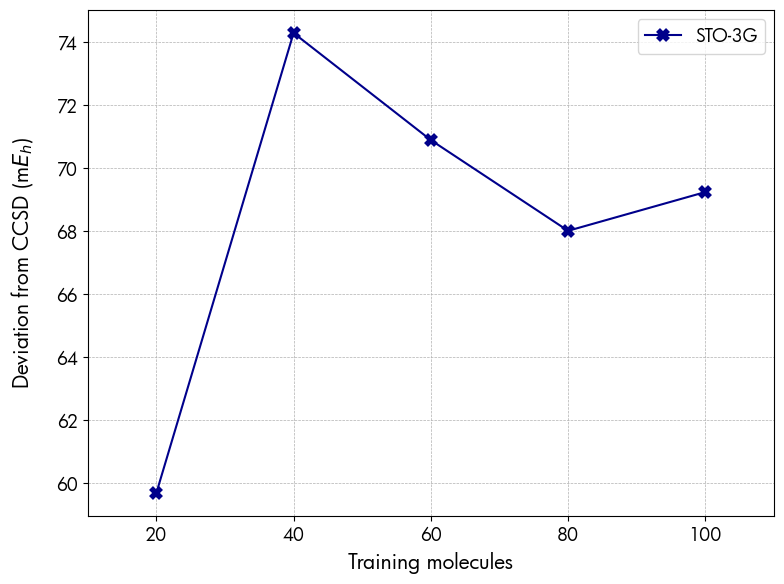

In [57]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

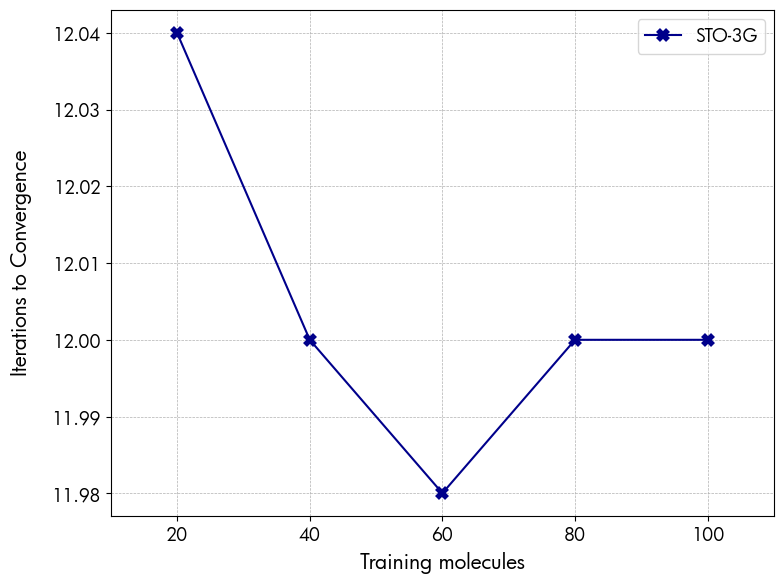

In [58]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to Convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()